In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import warnings
import os
warnings.filterwarnings('ignore')

In [2]:
def wape_plus_rbias(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    s = y_true.sum()
    if s == 0:
        return 0.0
    return np.abs(y_pred - y_true).sum() / s + np.abs(y_pred.sum() / s - 1)

In [3]:
train = pd.read_parquet('train_team_track.parquet')
test = pd.read_parquet('test_team_track.parquet')
train['timestamp'] = pd.to_datetime(train['timestamp'])
test['timestamp'] = pd.to_datetime(test['timestamp'])

route_to_office = train.groupby('route_id')['office_from_id'].first().to_dict()
test['office_from_id'] = test['route_id'].map(route_to_office)

status_cols = [f'status_{i}' for i in range(1, 9)]
for c in status_cols:
    test[c] = np.nan

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
        
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [ ]:
MODE = 'experiment'

configs = {
    'experiment': {
        'sample_routes': 200,
        'epochs': 10,
        'patience': 3,
        'batch_size': 4096
    },
    'validation': {
        'sample_routes': 500,
        'epochs': 20,
        'patience': 5,
        'batch_size': 2048
    },
    'final': {
        'sample_routes': None,
        'epochs': 40,
        'patience': 8,
        'batch_size': 2048
    }
}

cfg = configs[MODE]
print(f"MODE: {MODE}")
print(f"Config: {cfg}")

EPOCHS = cfg['epochs']
PATIENCE = cfg['patience']
BS = cfg['batch_size']

if cfg['sample_routes']:
    sample_routes = np.random.choice(
        train['route_id'].unique(),
        size=cfg['sample_routes'],
        replace=False
    )
    train = train[train['route_id'].isin(sample_routes)].copy()

In [4]:
class LogRobustScaler:
    def __init__(self):
        self.medians = {}
        self.iqrs = {}
        self.use_log = {}

    def fit(self, df, columns, log_columns=None):
        log_columns = log_columns or []
        for col in columns:
            v = df[col].dropna().values.copy()
            if col in log_columns:
                v = np.log1p(np.clip(v, 0, None))
                self.use_log[col] = True
            else:
                self.use_log[col] = False
            q25, q75 = np.percentile(v, [25, 75])
            self.medians[col] = np.median(v)
            self.iqrs[col] = max(q75 - q25, 1e-5)
        return self

    def transform(self, values, col):
        v = np.array(values, dtype=float)
        if self.use_log.get(col, False):
            v = np.log1p(np.clip(v, 0, None))
        return (v - self.medians[col]) / self.iqrs[col]

    def inverse_transform(self, values, col):
        v = np.array(values, dtype=float)
        v = v * self.iqrs[col] + self.medians[col]
        if self.use_log.get(col, False):
            v = np.expm1(v)
        return v

log_cols = status_cols + ['target_2h']
scaler = LogRobustScaler()
scaler.fit(train, log_cols, log_columns=log_cols)

In [5]:
def add_time_features(df):
    df = df.copy()
    df['time_slot'] = df['timestamp'].dt.hour * 2 + df['timestamp'].dt.minute // 30
    df['day_of_week'] = df['timestamp'].dt.dayofweek
    df['hour'] = df['timestamp'].dt.hour
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(float)
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['slot_sin'] = np.sin(2 * np.pi * df['time_slot'] / 48)
    df['slot_cos'] = np.cos(2 * np.pi * df['time_slot'] / 48)
    df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
    return df

train = add_time_features(train)
test = add_time_features(test)

time_features = ['hour_sin', 'hour_cos', 'slot_sin', 'slot_cos',
                 'dow_sin', 'dow_cos', 'is_weekend']

seq_cols = status_cols + ['target_2h']  # 9 нормализуемых
num_seq_features = len(seq_cols) + len(time_features)  # 9 + 7 = 16

In [6]:
WINDOW_SIZE = 48

print("Building sequences efficiently...")

train_sorted = train

feature_cols_in_window = [f'{c}_norm' for c in seq_cols] + time_features

for c in seq_cols:
    train_sorted[f'{c}_norm'] = scaler.transform(train_sorted[c].values, c)

all_X = []
all_y = []
all_rids = []
all_oids = []
all_ts = []

norm_cols = [f'{c}_norm' for c in seq_cols]
feature_matrix = train_sorted[norm_cols + time_features].values

route_groups = train_sorted.groupby('route_id', sort=False)

for rid, group_indices in route_groups.groups.items():
    indices = group_indices.values
    n_rows = len(indices)
    
    if n_rows <= WINDOW_SIZE:
        continue
    
    route_features = feature_matrix[indices]
    route_target = train_sorted.loc[indices, 'target_2h_norm'].values
    route_ts = train_sorted.loc[indices, 'timestamp'].values
    route_oid = train_sorted.loc[indices[0], 'office_from_id']
    
    for i in range(WINDOW_SIZE, n_rows):
        all_X.append(route_features[i - WINDOW_SIZE:i])
        all_y.append(route_target[i])
        all_rids.append(rid)
        all_oids.append(route_oid)
        all_ts.append(route_ts[i])

all_X = np.array(all_X, dtype=np.float16)
all_y = np.array(all_y, dtype=np.float16)
all_rids = np.array(all_rids, dtype=np.int16)
all_oids = np.array(all_oids, dtype=np.int16)
all_ts = np.array(all_ts)

print(f"Sequences: {all_X.shape}")

Building sequences efficiently...
Sequences: (4294000, 48, 16)
Memory: 6.14 GB


In [7]:
last_10_timestamps = sorted(train['timestamp'].unique())[-10:]
last_10_timestamps_np = pd.to_datetime(last_10_timestamps).to_numpy()
print(f"\nValidation timestamps (last 10): {last_10_timestamps[0]} — {last_10_timestamps[-1]}")

val_mask = np.isin(all_ts, last_10_timestamps_np)
train_mask = ~val_mask

X_tr, y_tr = all_X[train_mask], all_y[train_mask]
r_tr, o_tr = all_rids[train_mask], all_oids[train_mask]
X_va, y_va = all_X[val_mask], all_y[val_mask]
r_va, o_va = all_rids[val_mask], all_oids[val_mask]

print(f"Train: {X_tr.shape[0]:,}, Val: {X_va.shape[0]:,}")


Validation timestamps (last 10): 2025-05-30 06:00:00 — 2025-05-30 10:30:00
Train: 4,284,000, Val: 10,000


In [8]:
class TSDataset(Dataset):
    def __init__(self, X, y, r, o):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
        self.r = torch.LongTensor(r)
        self.o = torch.LongTensor(o)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.r[i], self.o[i], self.y[i]

train_loader = DataLoader(TSDataset(X_tr, y_tr, r_tr, o_tr),
                          batch_size=BS, shuffle=True, pin_memory=True)
val_loader = DataLoader(TSDataset(X_va, y_va, r_va, o_va),
                        batch_size=BS * 2, shuffle=False, pin_memory=True)

In [9]:
class DeliveryNet(nn.Module):
    def __init__(self, nf=16, nr=1000, no=54,
                 re=32, oe=16, ch=64, lh=128, ll=2, dr=0.2):
        super().__init__()
        self.r_emb = nn.Embedding(nr, re)
        self.o_emb = nn.Embedding(no, oe)

        self.cnn = nn.Sequential(
            nn.Conv1d(nf, ch, 3, padding=1), nn.BatchNorm1d(ch), nn.GELU(),
            nn.Conv1d(ch, ch, 3, padding=1), nn.BatchNorm1d(ch), nn.GELU(),
        )
        self.lstm = nn.LSTM(ch, lh, ll, batch_first=True,
                            dropout=dr if ll > 1 else 0)
        self.ln = nn.LayerNorm(lh)

        self.attn = nn.Sequential(
            nn.Linear(lh, lh // 2), nn.Tanh(), nn.Linear(lh // 2, 1))

        head_in = lh * 2 + re + oe
        self.head = nn.Sequential(
            nn.Linear(head_in, 128), nn.GELU(), nn.Dropout(dr),
            nn.Linear(128, 64), nn.GELU(), nn.Dropout(dr),
            nn.Linear(64, 1)
        )

    def forward(self, x, rid, oid):
        h = self.cnn(x.permute(0, 2, 1)).permute(0, 2, 1)
        h, _ = self.lstm(h)
        h = self.ln(h)

        w = torch.softmax(self.attn(h), dim=1)
        ctx = (h * w).sum(dim=1)

        last = h[:, -1, :]

        r = self.r_emb(rid)
        o = self.o_emb(oid)
        return self.head(torch.cat([ctx, last, r, o], dim=1)).squeeze(-1)

In [10]:
model = DeliveryNet(nf=num_seq_features).to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Parameters: 335,970


In [11]:
class WapeBiasLoss(nn.Module):
    def __init__(self, bias_w=0.3):
        super().__init__()
        self.bias_w = bias_w
    def forward(self, p, t):
        return (p - t).abs().mean() + self.bias_w * (p.mean() - t.mean()).abs()

criterion = WapeBiasLoss(0.3)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-5)

In [12]:
best_metric, best_epoch, best_state = float('inf'), 0, None
checkpoint_path = 'best_model.pth'

In [13]:
print("\nTraining...")
for ep in range(EPOCHS):
    model.train()
    losses = []
    for xb, rb, ob, yb in train_loader:
        xb, rb, ob, yb = [t.to(device) for t in [xb, rb, ob, yb]]
        optimizer.zero_grad()
        loss = criterion(model(xb, rb, ob), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        losses.append(loss.item())
    scheduler.step()

    model.eval()
    vp, vt = [], []
    with torch.no_grad():
        for xb, rb, ob, yb in val_loader:
            vp.append(model(xb.to(device), rb.to(device), ob.to(device)).cpu().numpy())
            vt.append(yb.numpy())

    vp_d = np.clip(scaler.inverse_transform(np.concatenate(vp), 'target_2h'), 0, None)
    vt_d = scaler.inverse_transform(np.concatenate(vt), 'target_2h')
    m = wape_plus_rbias(vt_d, vp_d)

    if m < best_metric:
        best_metric, best_epoch = m, ep
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        
        torch.save({
            'epoch': ep,
            'model_state': best_state,
            'metric': best_metric,
            'optimizer_state': optimizer.state_dict(),
        }, checkpoint_path)
        print(f"  → Saved checkpoint: {checkpoint_path}")


    w = np.abs(vp_d - vt_d).sum() / vt_d.sum()
    b = np.abs(vp_d.sum() / vt_d.sum() - 1)
    print(f"Ep {ep:3d} | L {np.mean(losses):.4f} | "
          f"M {m:.4f} (W:{w:.4f} B:{b:.4f})"
          f"{' *' if m <= best_metric else ''}")

    if ep - best_epoch >= PATIENCE:
        print(f"Early stop at {ep}")
        break


Training...
  → Saved checkpoint: best_model.pth
Ep   0 | L 0.1601 | M 0.2429 (W:0.1576 B:0.0854) *
  → Saved checkpoint: best_model.pth
Ep   1 | L 0.1415 | M 0.1797 (W:0.1465 B:0.0332) *
Ep   2 | L 0.1379 | M 0.1802 (W:0.1446 B:0.0356)
Ep   3 | L 0.1354 | M 0.1909 (W:0.1424 B:0.0485)
  → Saved checkpoint: best_model.pth
Ep   4 | L 0.1336 | M 0.1595 (W:0.1438 B:0.0157) *
Ep   5 | L 0.1317 | M 0.1801 (W:0.1423 B:0.0378)
Ep   6 | L 0.1299 | M 0.1646 (W:0.1425 B:0.0221)
Ep   7 | L 0.1285 | M 0.1608 (W:0.1425 B:0.0183)
Ep   8 | L 0.1272 | M 0.1675 (W:0.1410 B:0.0264)
  → Saved checkpoint: best_model.pth
Ep   9 | L 0.1264 | M 0.1586 (W:0.1422 B:0.0164) *
Ep  10 | L 0.1331 | M 0.1653 (W:0.1458 B:0.0195)
Ep  11 | L 0.1326 | M 0.1868 (W:0.1448 B:0.0420)
  → Saved checkpoint: best_model.pth
Ep  12 | L 0.1317 | M 0.1481 (W:0.1475 B:0.0006) *
Ep  13 | L 0.1311 | M 0.1561 (W:0.1458 B:0.0103)
Ep  14 | L 0.1302 | M 0.1669 (W:0.1431 B:0.0238)
Ep  15 | L 0.1296 | M 0.1517 (W:0.1473 B:0.0044)
Ep  16 |

In [14]:
print(f"\nBest: ep {best_epoch}, metric {best_metric:.6f}")
model.load_state_dict(best_state)
model = model.to(device)


Best: ep 12, metric 0.148115


In [36]:
print("\nTest prediction (10 steps, mostly real data)...")

route_histories = {}
route_raw_statuses = {}

for rid in sorted(train_sorted['route_id'].unique()):
    rd = train_sorted[train_sorted['route_id'] == rid].sort_values('timestamp')
    norm_parts = [scaler.transform(rd[c].values, c) for c in seq_cols]
    norm_arr = np.column_stack(norm_parts)
    time_arr = rd[time_features].values
    full = np.column_stack([norm_arr, time_arr]).astype(np.float32)
    route_histories[rid] = list(full)
    route_raw_statuses[rid] = rd[status_cols].values.tolist()

test_sorted = test.sort_values(['timestamp', 'route_id'])
test_timestamps = sorted(test['timestamp'].unique())

id_to_pred = {}

model.eval()

for step, ts in enumerate(test_timestamps):
    real_pct = (WINDOW_SIZE - step) / WINDOW_SIZE * 100
    print(f"  Step {step+1}/10: {ts} | {real_pct:.0f}% real statuses in window")

    batch_df = test_sorted[test_sorted['timestamp'] == ts]
    rids = batch_df['route_id'].values.astype(int)
    oids = batch_df['office_from_id'].values.astype(int)
    batch_ids = batch_df['id'].values

    batch_X = []
    for rid in rids:
        h = route_histories[rid]
        if len(h) >= WINDOW_SIZE:
            w = np.array(h[-WINDOW_SIZE:], dtype=np.float32)
        else:
            pad = WINDOW_SIZE - len(h)
            w = np.array([h[0]] * pad + list(h), dtype=np.float32)
        batch_X.append(w)

    batch_X = np.nan_to_num(np.array(batch_X), nan=0.0)

    with torch.no_grad():
        preds_norm = model(
            torch.FloatTensor(batch_X).to(device),
            torch.LongTensor(rids).to(device),
            torch.LongTensor(oids).to(device)
        ).cpu().numpy()

    preds = np.clip(scaler.inverse_transform(preds_norm, 'target_2h'), 0, None)

    for j, (_, row) in enumerate(batch_df.iterrows()):
        rid = int(row['route_id'])
        original_id = row['id']

        id_to_pred[original_id] = preds[j]

        raw = route_raw_statuses[rid]
        if len(raw) >= 4:
            approx = np.mean(raw[-4:], axis=0)
        else:
            approx = np.array(raw[-1]) if raw else np.zeros(8)

        norm_s = [scaler.transform(np.array([approx[k]]), status_cols[k])[0]
                  for k in range(8)]
        t_norm = preds_norm[j]
        t_vals = [row[f] for f in time_features]

        new_step = np.array(norm_s + [t_norm] + t_vals, dtype=np.float32)
        route_histories[rid].append(new_step)
        route_raw_statuses[rid].append(approx.tolist())



Test prediction (10 steps, mostly real data)...
  Step 1/10: 2025-05-30 11:00:00 | 100% real statuses in window
  Step 2/10: 2025-05-30 11:30:00 | 98% real statuses in window
  Step 3/10: 2025-05-30 12:00:00 | 96% real statuses in window
  Step 4/10: 2025-05-30 12:30:00 | 94% real statuses in window
  Step 5/10: 2025-05-30 13:00:00 | 92% real statuses in window
  Step 6/10: 2025-05-30 13:30:00 | 90% real statuses in window
  Step 7/10: 2025-05-30 14:00:00 | 88% real statuses in window
  Step 8/10: 2025-05-30 14:30:00 | 85% real statuses in window
  Step 9/10: 2025-05-30 15:00:00 | 83% real statuses in window
  Step 10/10: 2025-05-30 15:30:00 | 81% real statuses in window


In [16]:
submission = pd.DataFrame({
    'id': list(id_to_pred.keys()),
    'y_pred': list(id_to_pred.values())
})
submission = submission.sort_values('id').reset_index(drop=True)

In [18]:
assert len(submission) == len(test), \
    f"Row count mismatch: {len(submission)} vs {len(test)}"
assert set(submission['id']) == set(test['id']), "Missing or extra ids!"
assert submission['id'].nunique() == len(submission), "Duplicate ids!"
assert submission['y_pred'].isna().sum() == 0, "NaN in predictions!"
assert (submission['y_pred'] >= 0).all(), "Negative predictions!"

submission.to_csv('submission_nn2.csv', index=False)
print(f"\nDone! {submission.shape}")
print(f"Sum: {submission['y_pred'].sum():.0f}")
print(submission.head(10))


Done! (10000, 2)
Sum: 664961
   id     y_pred
0   0  84.001763
1   1  82.075838
2   2  66.243959
3   3   9.198947
4   4  10.002159
5   5  12.505913
6   6  14.512948
7   7  13.398390
8   8  13.477918
9   9  13.175917


In [21]:
torch.save(model.state_dict(), 'model_weights2.pth')

# Диагностика проблемы

In [30]:
model.eval()
vp, vt = [], []
with torch.no_grad():
    for xb, rb, ob, yb in val_loader:
        vp.append(model(xb.to(device), rb.to(device), ob.to(device)).cpu().numpy())
        vt.append(yb.numpy())

vp_d = np.clip(scaler.inverse_transform(np.concatenate(vp), 'target_2h'), 0, None)
vt_d = scaler.inverse_transform(np.concatenate(vt), 'target_2h')

errors = np.abs(vp_d - vt_d)
rel_errors = errors / (vt_d + 1e-5)

print("Error stats:")
print(f"  MAE: {errors.mean():.4f}")
print(f"  RMSE: {np.sqrt((errors**2).mean()):.4f}")
print(f"  Max error: {errors.max():.4f}")
print(f"  Median error: {np.median(errors):.4f}")
print(f"  90th percentile: {np.percentile(errors, 90):.4f}")
print(f"  % with error > 50: {(errors > 50).mean() * 100:.1f}%")

Error stats:
  MAE: 9.7224
  RMSE: 18.4132
  Max error: 312.1144
  Median error: 4.8893
  90th percentile: 23.1390
  % with error > 50: 2.5%


In [32]:
val_df = pd.DataFrame({
    'route_id': r_va,
    'true': vt_d,
    'pred': vp_d
})
route_errors = val_df.groupby('route_id').apply(
    lambda g: np.abs(g['pred'] - g['true']).mean()
).sort_values(ascending=False)
print("\nWorst 10 routes:")
print(route_errors.head(10))


Worst 10 routes:
route_id
268    89.461111
889    81.693940
675    68.202894
897    63.915939
733    60.235569
717    57.720207
301    56.244858
519    55.980421
777    55.393773
31     53.351999
dtype: float64



Error by prediction step:
           mean    median        std
step                                
0      9.759425  4.680324  13.203971
1      9.121428  4.933077  12.403719
2     10.254175  4.512528  22.039957
3     10.188724  5.540295  13.988060
4     10.515642  5.470763  13.883590
5     10.308020  5.118307  22.741625
6      9.274329  4.849677  13.734419
7      9.847091  5.402965  12.265239
8      8.292172  4.277242  10.893548
9      9.663096  4.409068  16.317714


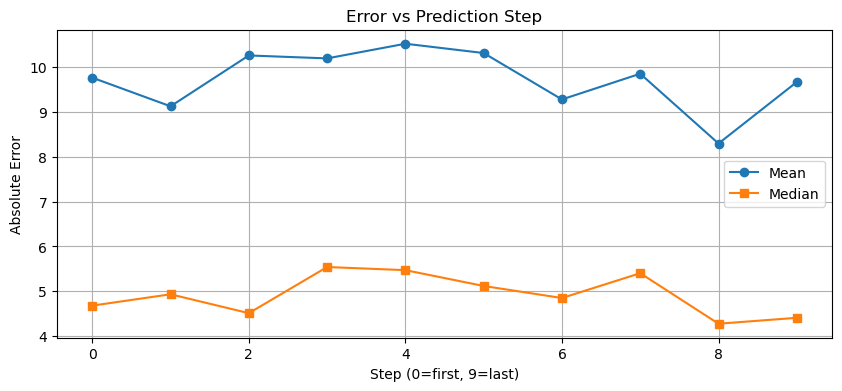

In [33]:
val_df['error'] = np.abs(val_df['pred'] - val_df['true'])
val_df['step'] = val_df.groupby('route_id').cumcount()

error_by_step = val_df.groupby('step')['error'].agg(['mean', 'median', 'std'])
print("\nError by prediction step:")
print(error_by_step)

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.plot(error_by_step.index, error_by_step['mean'], marker='o', label='Mean')
plt.plot(error_by_step.index, error_by_step['median'], marker='s', label='Median')
plt.xlabel('Step (0=first, 9=last)')
plt.ylabel('Absolute Error')
plt.title('Error vs Prediction Step')
plt.legend()
plt.grid()
plt.show()

In [38]:
worst_routes = [268, 889, 675, 897, 733, 717, 301, 519, 777, 31]

for rid in worst_routes[:3]:
    route_val = val_df[val_df['route_id'] == rid]
    print(f"\nRoute {rid} (MAE={route_val['error'].mean():.1f}):")
    print(f"  Train samples: {len(train[train['route_id'] == rid])}")
    print(f"  Val samples:   {len(route_val)}")
    print(f"  Mean target:   {route_val['true'].mean():.1f}")
    print(f"  Mean pred:     {route_val['pred'].mean():.1f}")
    print(f"  Target range:  {route_val['true'].min():.1f} - {route_val['true'].max():.1f}")
    
    route_train = train[train['route_id'] == rid].copy()
    route_train['time_slot'] = route_train['timestamp'].dt.hour * 2 + route_train['timestamp'].dt.minute // 30
    profile = route_train.groupby('time_slot')['target_2h'].agg(['mean', 'std'])
    print(f"  Target variability (CV): {(profile['std'] / profile['mean']).mean():.2f}")


Route 268 (MAE=89.5):
  Train samples: 4342
  Val samples:   10
  Mean target:   433.4
  Mean pred:     373.5
  Target range:  150.0 - 636.1
  Target variability (CV): 0.71

Route 889 (MAE=81.7):
  Train samples: 4342
  Val samples:   10
  Mean target:   302.3
  Mean pred:     275.3
  Target range:  114.0 - 486.7
  Target variability (CV): 0.73

Route 675 (MAE=68.2):
  Train samples: 4342
  Val samples:   10
  Mean target:   222.6
  Mean pred:     190.5
  Target range:  31.0 - 371.7
  Target variability (CV): 1.31
